# EDA Cars Datasets (2025)

## Import Packages

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

### Loading Cars Dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdulmalik1518/cars-datasets-2025")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/cars-datasets-2025


In [4]:
from google.colab import files

uploaded = files.upload()

Saving Cars Datasets 2025.csv to Cars Datasets 2025.csv


In [6]:
df = pd.read_csv('Cars Datasets 2025.csv', encoding='latin-1')

df

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm
...,...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487 cc,240 hp,180 km/h,7.6 sec,"$43,590  $48,000",Hybrid (Gas + Electric),5,239 Nm
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326 hp,180 km/h,6.8 sec,"$50,000",Hybrid,7,630 Nm
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,169  196 hp,190 km/h,8.0  9.2 sec,"$25,210  $29,135",Gas / Hybrid,5,190  210 Nm
1216,Toyota,C-HR+,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,140  198 hp,180 km/h,7.9  10.5 sec," 33,000",Hybrid,5,190  205 Nm


### Brands Market Share

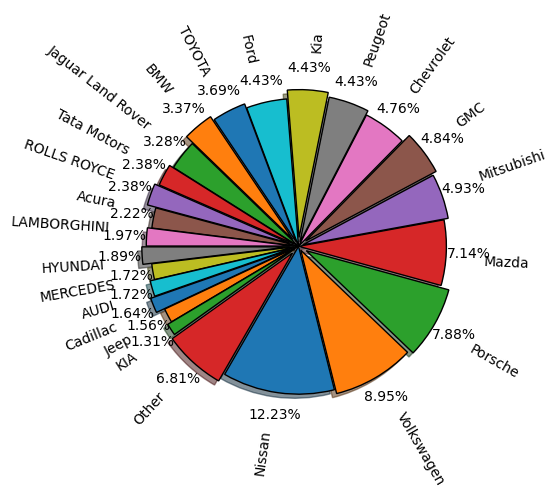

In [7]:
#Number of cars for each brand
pie = df['Company Names'].value_counts()
#will add a new column to the pie with other containing all the other brands
pie_main = pie[pie > 15]
pie_other = pie[pie <= 15].sum()
pie_main['Other'] = pie_other
explode = np.array(range(len(pie_main)))
explode = explode % 3 * 0.03
plt.pie(pie_main,shadow=1,explode=explode,pctdistance=1.15, labeldistance=1.25 , labels=pie_main.index, autopct='%1.2f%%',rotatelabels=1, startangle=240,
        wedgeprops = {"edgecolor" : "black",
                      'linewidth': 1,
                      'antialiased': True},)
plt.show()

* Nissan has the most models with 12.23% of Models

* Volkswagen in 2nd place with 8.95%

* Porsche and Mazda in 3rd, 4th with 7.88% and 7.14%

In [8]:
# Total Speed column cleaning. Will be used later.
df['Total Speed km/h'] = df['Total Speed'].str.replace(r"\s*\(est\.\)|\s*km/h", '', regex=True).astype(int)
pd.DataFrame(df['Total Speed km/h'])

,Total Speed km/h
0,340
1,250
2,165
3,250
4,320
...,...
1213,180
1214,180
1215,190
1216,180


### Finding The Fastest Cars

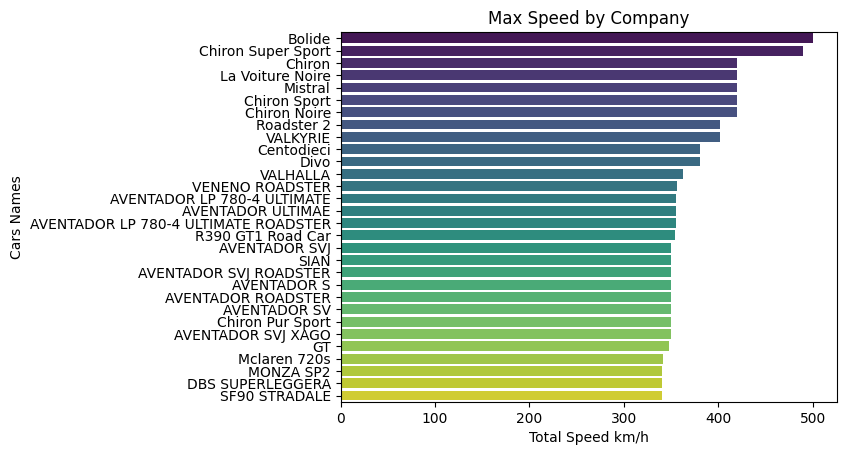

,Cars Names,Company Names,Total Speed km/h
0,Bolide,Bugatti,500
1,Chiron Super Sport,Bugatti,490
2,Chiron,Bugatti,420
3,La Voiture Noire,Bugatti,420
4,Mistral,Bugatti,420
5,Chiron Sport,Bugatti,420
6,Chiron Noire,Bugatti,420
7,Roadster 2,Tesla,402
8,VALKYRIE,ASTON MARTIN,402
9,Centodieci,Bugatti,380


In [9]:
import seaborn as sns

GSpeedComp = df[['Cars Names','Total Speed km/h','Company Names']].groupby(['Cars Names','Company Names']).max().reset_index().sort_values(by='Total Speed km/h', ascending=False).head(30)
sns.barplot(x='Total Speed km/h', y='Cars Names',data=GSpeedComp, palette='viridis')
plt.title('Max Speed by Company')
plt.show()
pd.DataFrame(GSpeedComp).head(10).reset_index(drop=True)

* Bugatti Bolide is in the lead with 8 out of top 10 cars in speed
* Next ASTON MARTIN and Tesla 356

### Top Engines in average speed

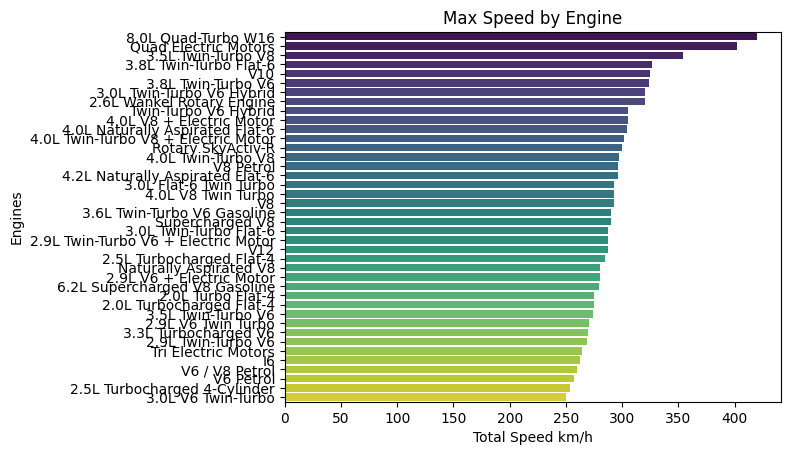

,Engines,Total Speed km/h
0,8.0L Quad-Turbo W16,420.000000
1,Quad Electric Motors,402.000000
2,3.5L Twin-Turbo V8,354.000000
3,3.8L Twin-Turbo Flat-6,326.857143
4,V10,325.000000
5,3.8L Twin-Turbo V6,324.000000
6,3.0L Twin-Turbo V6 Hybrid,320.000000
7,2.6L Wankel Rotary Engine,320.000000
8,Twin-Turbo V6 Hybrid,305.250000
9,4.0L V8 + Electric Motor,305.000000


In [10]:
GSpeedComp = df[['Engines','Total Speed km/h']].groupby(['Engines']).mean().reset_index().sort_values(by='Total Speed km/h', ascending=False).head(40)
sns.barplot(x='Total Speed km/h', y='Engines',data=GSpeedComp, palette='viridis')
plt.title('Max Speed by Engine')
plt.show()
pd.DataFrame(GSpeedComp).head(10).reset_index(drop=True)

* 8.0L Quad-Turbo W16 is in the lead with mean of 420 km/h

* Next Quad Electric Motors with 402 km/h

* Next 3.5L Twin-Turbo V8 with 354 km/h

In [11]:
#Compining the fuel types to make it easier to work with.
df['Clean Fuel Types'] = df['Fuel Types'].str.replace('plug in', 'Plug-in').str.replace('(\s*\/\s*)', ' ',regex=True).str.replace(',','')
df['Clean Fuel Types'] = df['Clean Fuel Types'].str.replace('Hybrid (Petrol)','Petrol Hybrid').replace('Petrol (Hybrid)','Petrol Hybrid').replace('Petrol AWD','Petrol').replace('Plug-in Hybrid','Petrol Hybrid').replace('Petrol EV','Petrol Hybrid').replace("Hybrid Electric",'Petrol Hybrid').replace("Diesel Petrol",'Petrol Diesel')
df['Clean Fuel Types'] = df['Clean Fuel Types'].str.replace('Hybrid (Gas + Electric)','Gas Hybrid').replace('Hybrid Plug-in','Petrol Hybrid').replace('Plug-in hyrbrid','Petrol Hybrid').replace('Hybrid','Petrol Hybrid').replace('CNG Petrol','Petrol').replace('Hybrid Petrol','Petrol Hybrid')
pd.DataFrame(df['Clean Fuel Types'].unique())

,0
0,Petrol Hybrid
1,Petrol
2,Diesel
3,Electric
4,Petrol Diesel
5,Hydrogen
6,Diesel Hybrid
7,Gas Hybrid


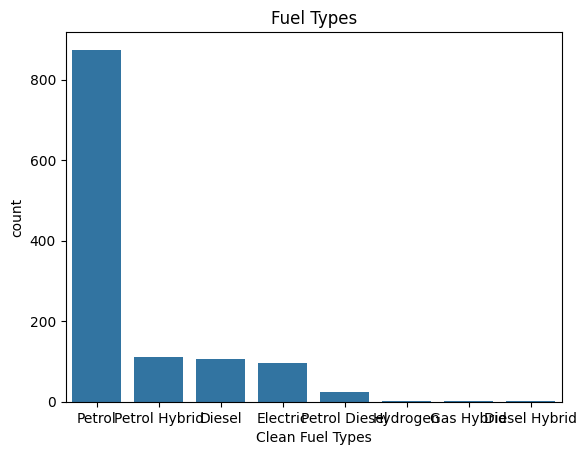

In [12]:
sns.countplot(x='Clean Fuel Types', data=df, order=df['Clean Fuel Types'].value_counts().index)
plt.title('Fuel Types')
plt.show()

In [13]:
df.describe()

,Total Speed km/h
count,1218.000000
mean,216.467159
std,53.051077
min,80.000000
25%,180.000000
50%,200.000000
75%,250.000000
max,500.000000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1217 non-null   object
 11  Total Speed km/h           1218 non-null   int64 
 12  Clean Fuel Types           1218 non-null   object
dtypes: int64(1), object(12)
memory usage: 123.8+ KB


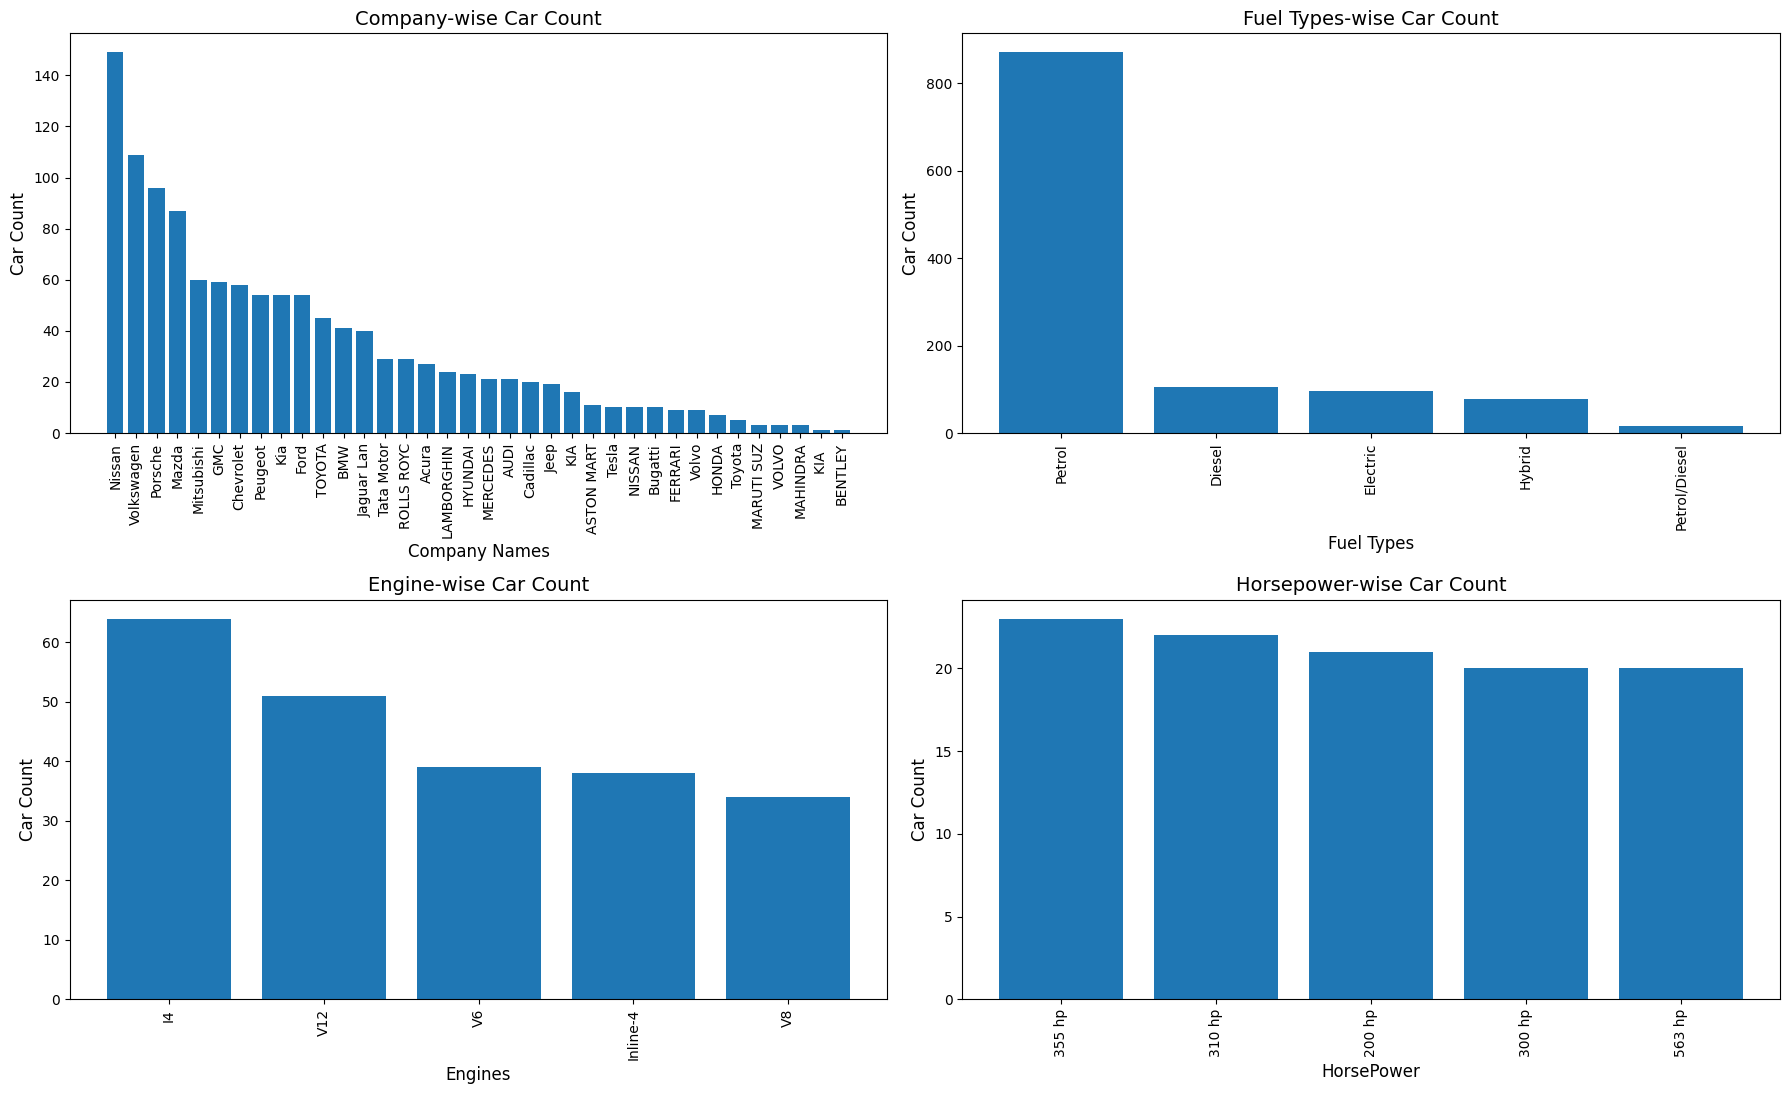

In [15]:
company_count = df['Company Names'].value_counts()


fuel_type_count = df['Fuel Types'].value_counts().nlargest()
engine_count = df['Engines'].value_counts().nlargest(5)


horsepower_count = df['HorsePower'].value_counts().nlargest(5)


fig, axs = plt.subplots(2, 2, figsize=(18, 12))

axs[0, 0].bar(company_count.index.str[:10], company_count.values)
axs[0, 0].set_title('Company-wise Car Count', fontsize=14)
axs[0, 0].set_xlabel('Company Names', fontsize=12)
axs[0, 0].set_ylabel('Car Count', fontsize=12)
axs[0, 0].tick_params(axis='x', rotation=90)

axs[0, 1].bar(fuel_type_count.index, fuel_type_count.values)
axs[0, 1].set_title('Fuel Types-wise Car Count', fontsize=14)
axs[0, 1].set_xlabel('Fuel Types', fontsize=12)
axs[0, 1].set_ylabel('Car Count', fontsize=12)
axs[0, 1].tick_params(axis='x', rotation=90)

axs[1, 0].bar(engine_count.index, engine_count.values)
axs[1, 0].set_title('Engine-wise Car Count', fontsize=14)
axs[1, 0].set_xlabel('Engines', fontsize=12)
axs[1, 0].set_ylabel('Car Count', fontsize=12)
axs[1, 0].tick_params(axis='x', rotation=90)
axs[1, 1].bar(horsepower_count.index, horsepower_count.values)
axs[1, 1].set_title('Horsepower-wise Car Count', fontsize=14)
axs[1, 1].set_xlabel('HorsePower', fontsize=12)
axs[1, 1].set_ylabel('Car Count', fontsize=12)
axs[1, 1].tick_params(axis='x', rotation=90)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

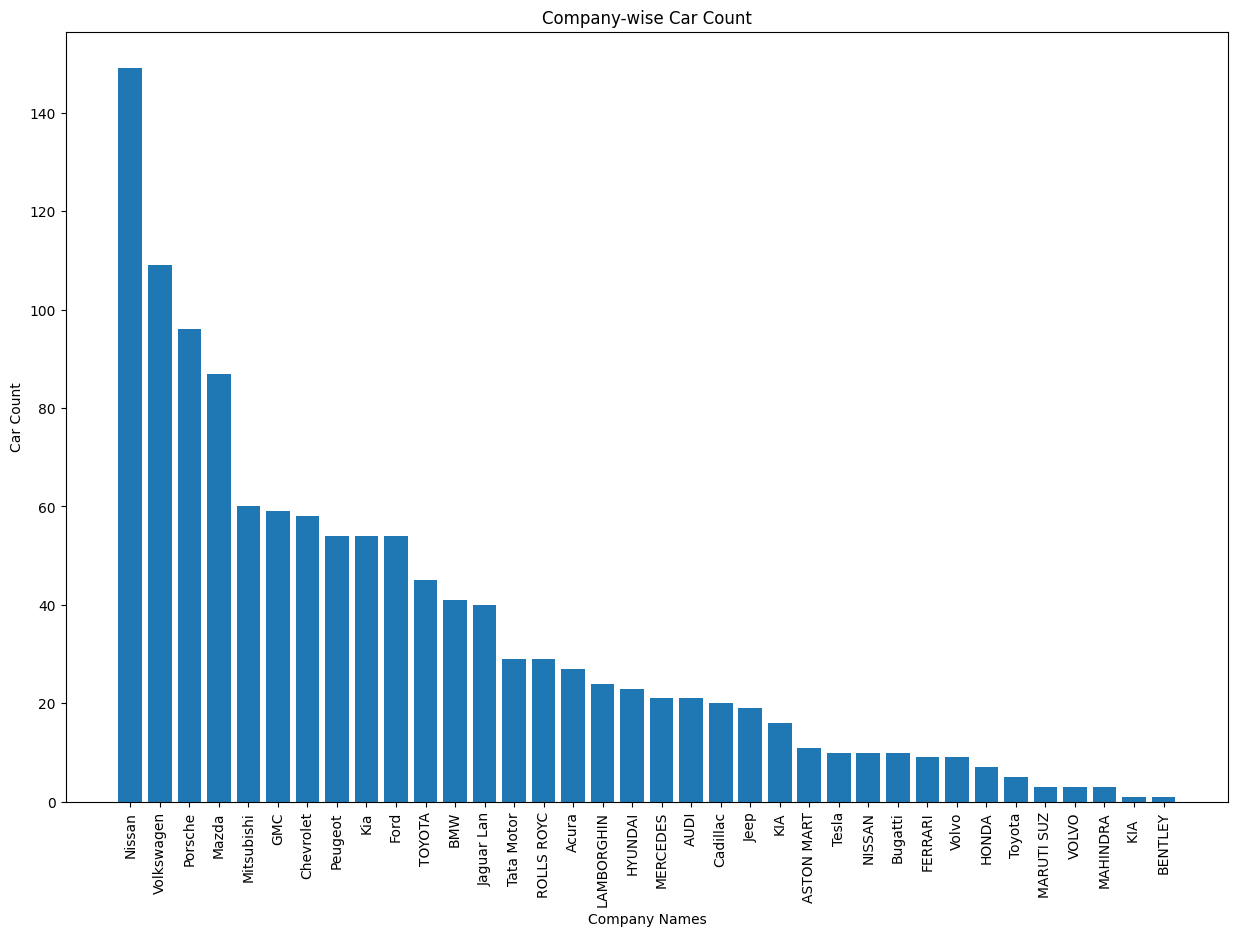

In [16]:
company_count = df['Company Names'].value_counts()


plt.figure(figsize=(15,10))
plt.bar(company_count.index.str[:10], company_count.values)
plt.xlabel('Company Names')
plt.ylabel('Car Count')
plt.title('Company-wise Car Count')
plt.xticks(rotation=90)
plt.show()

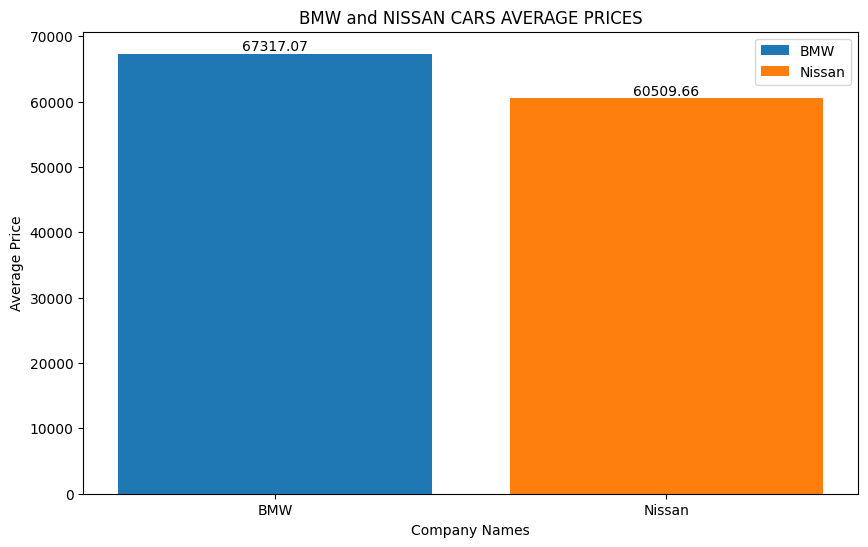

In [17]:
df['Cars Prices'] = df['Cars Prices'].str.replace('$', '').str.replace(',', '')


df['Cars Prices'] = pd.to_numeric(df['Cars Prices'], errors='coerce')


df = df.dropna(subset=['Cars Prices'])

bmw_cars = df[df['Company Names'] == 'BMW']
nissan_cars = df[df['Company Names'] == 'Nissan']

bmw_average_price = bmw_cars['Cars Prices'].mean()
nissan_average_price = nissan_cars['Cars Prices'].mean()




plt.figure(figsize=(10, 6))
plt.bar(['BMW'], [bmw_average_price], label='BMW')
plt.bar(['Nissan'], [nissan_average_price], label='Nissan')
plt.xlabel('Company Names')
plt.ylabel('Average Price')
plt.title('BMW and NISSAN CARS AVERAGE PRICES')
plt.legend()
plt.text(0, bmw_average_price, f'{bmw_average_price:.2f}', ha='center', va='bottom')
plt.text(1, nissan_average_price, f'{nissan_average_price:.2f}', ha='center', va='bottom')
plt.show()

In [18]:
df['Cars Prices'] = df['Cars Prices'].apply(lambda x: str(x))

df['Cars Prices'] = df['Cars Prices'].apply(lambda x: x.replace('$', '').replace(',', ''))

df['Cars Prices'] = pd.to_numeric(df['Cars Prices'], errors='coerce')

df = df[df['Cars Prices'].notnull()]

df['Cars Names'] = df['Cars Names'].apply(lambda x: str(x))
print(df[['Cars Names', 'Cars Prices']])

                        Cars Names  Cars Prices
0                    SF90 STRADALE    1100000.0
1                          PHANTOM     460000.0
3                          GT 63 S     161000.0
4                       AUDI R8 Gt     253290.0
5                     Mclaren 720s     499000.0
...                            ...          ...
1063                 Ranger (2024)      40000.0
1064  Escape Plug-in Hybrid (2024)      38000.0
1065                 Bronco (2024)      45000.0
1066               Explorer (2024)      55000.0
1214             4Runner (6th Gen)      50000.0

[1044 rows x 2 columns]


In [19]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df['Cars Prices'] = df['Cars Prices'].apply(lambda x: str(x))

df['Cars Prices'] = df['Cars Prices'].apply(lambda x: x.replace('$', '').replace(',', ''))

df['Cars Prices'] = pd.to_numeric(df['Cars Prices'], errors='coerce')

df = df[df['Cars Prices'].notnull()]

top_50_cars = df.sort_values(by='Cars Prices', ascending=False).head(50)

print("\nTop 50 Cars by Price:")
print(top_50_cars[['Company Names', 'Cars Names', 'Cars Prices']])

output_path = "top_50_cars_by_price_cleaned.csv"
top_50_cars.to_csv(output_path, index=False)
print(f"\nTop 50 cars saved to {output_path}")


Top 50 Cars by Price:
     Company Names                            Cars Names  Cars Prices
887        Bugatti                      La Voiture Noire   18000000.0
886        Bugatti                            Centodieci    9000000.0
885        Bugatti                                  Divo    5800000.0
889        Bugatti                               Mistral    5000000.0
8      LAMBORGHINI                       VENENO ROADSTER    4500000.0
888        Bugatti                                Bolide    4500000.0
882        Bugatti                    Chiron Super Sport    3500000.0
881        Bugatti                      Chiron Pur Sport    3300000.0
883        Bugatti                          Chiron Sport    3300000.0
884        Bugatti                          Chiron Noire    3300000.0
32    ASTON MARTIN                              VALKYRIE    3200000.0
880        Bugatti                                Chiron    3000000.0
42     LAMBORGHINI                                  SIAN    2800000

             Cars Names  HorsePower  Cars Prices
888              Bolide      1850.0    4500000.0
882  Chiron Super Sport      1600.0    3500000.0
886          Centodieci      1600.0    9000000.0
889             Mistral      1600.0    5000000.0
880              Chiron      1500.0    3000000.0
881    Chiron Pur Sport      1500.0    3300000.0
883        Chiron Sport      1500.0    3300000.0
884        Chiron Noire      1500.0    3300000.0
885                Divo      1500.0    5800000.0
887    La Voiture Noire      1500.0   18000000.0


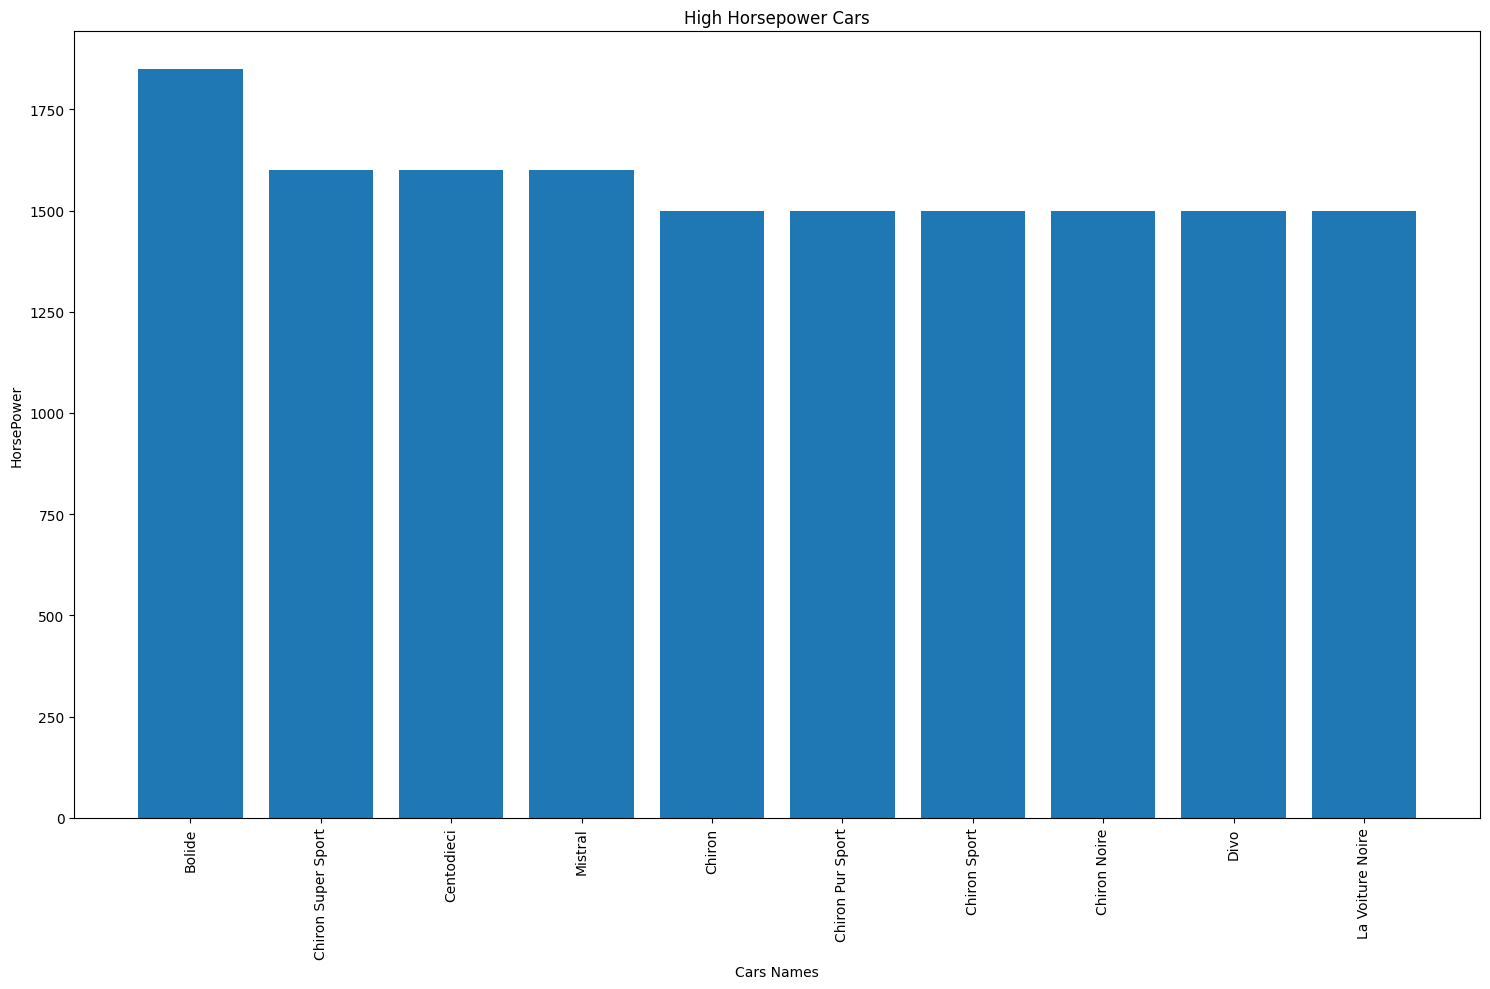

In [20]:
df['HorsePower'] = df['HorsePower'].str.replace('hp', '').str.replace(',', '')
df['HorsePower'] = pd.to_numeric(df['HorsePower'], errors='coerce')


df = df.dropna(subset=['HorsePower'])


max_horsepower_cars = df.nlargest(10, 'HorsePower')


print(max_horsepower_cars[['Cars Names', 'HorsePower', 'Cars Prices']])


plt.figure(figsize=(15, 10))
plt.bar(max_horsepower_cars['Cars Names'], max_horsepower_cars['HorsePower'])
plt.xlabel('Cars Names')
plt.ylabel('HorsePower')
plt.title('High Horsepower Cars')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [21]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


df['Torque'] = df['Torque'].str.replace(" Nm", "", regex=False)
df['Torque'] = df['Torque'].str.replace(",", "")
df['Torque'] = pd.to_numeric(df['Torque'], errors='coerce')
top_10_high_hp_cars = df.sort_values(by='Torque', ascending=False).head(10)

print("Top 10 Cars with Highest Torque:")
print(top_10_high_hp_cars[['Company Names','Cars Names', 'Torque']])

Top 10 Cars with Highest Torque:
    Company Names          Cars Names   Torque
668         Tesla          Roadster 2  10000.0
891         Volvo          Volvo FH16   3500.0
890         Volvo            Volvo FH   2600.0
893         Volvo           Volvo FMX   2500.0
896         Volvo           Volvo VHD   2500.0
894         Volvo           Volvo VNL   2400.0
892         Volvo            Volvo FM   2200.0
895         Volvo           Volvo VNR   1800.0
885       Bugatti                Divo   1600.0
882       Bugatti  Chiron Super Sport   1600.0


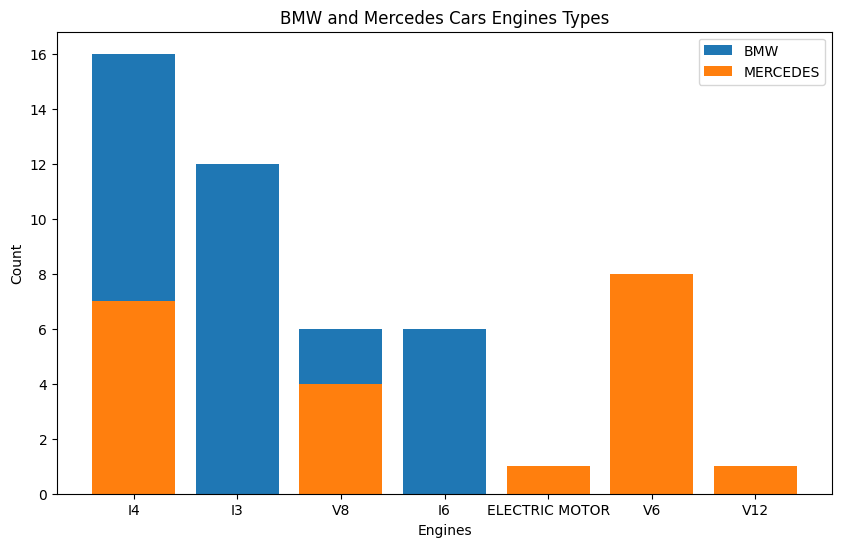

In [22]:
bmw_cars = df[df['Company Names'] == 'BMW']
mercedes_cars = df[df['Company Names'] == 'MERCEDES']


bmw_engine_types = bmw_cars['Engines'].value_counts()
mercedes_engine_types = mercedes_cars['Engines'].value_counts()


plt.figure(figsize=(10, 6))
plt.bar(bmw_engine_types.index, bmw_engine_types.values, label='BMW')
plt.bar(mercedes_engine_types.index, mercedes_engine_types.values, label='MERCEDES')
plt.xlabel('Engines')
plt.ylabel('Count')
plt.title('BMW and Mercedes Cars Engines Types')
plt.legend()
plt.show()

In [23]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df['Cars Prices'] = df['Cars Prices'].apply(lambda x: str(x))

df['Cars Prices'] = df['Cars Prices'].str.replace('$', '').str.replace(',', '')

df['Cars Prices'] = pd.to_numeric(df['Cars Prices'], errors='coerce')

df = df.dropna(subset=['Cars Prices'])

nissan_cars = df[df['Company Names'] == 'Nissan']
volkswagen_cars = df[df['Company Names'] == 'Volkswagen']

nissan_avg_price = nissan_cars['Cars Prices'].mean()
volkswagen_avg_price = volkswagen_cars['Cars Prices'].mean()

if nissan_avg_price > volkswagen_avg_price:
    print("Nissan company cars are expensive")
elif volkswagen_avg_price > nissan_avg_price:
    print("Volkswagen company cars are expensive")
else:
    print("Both companies cars prices are same")

Volkswagen company cars are expensive


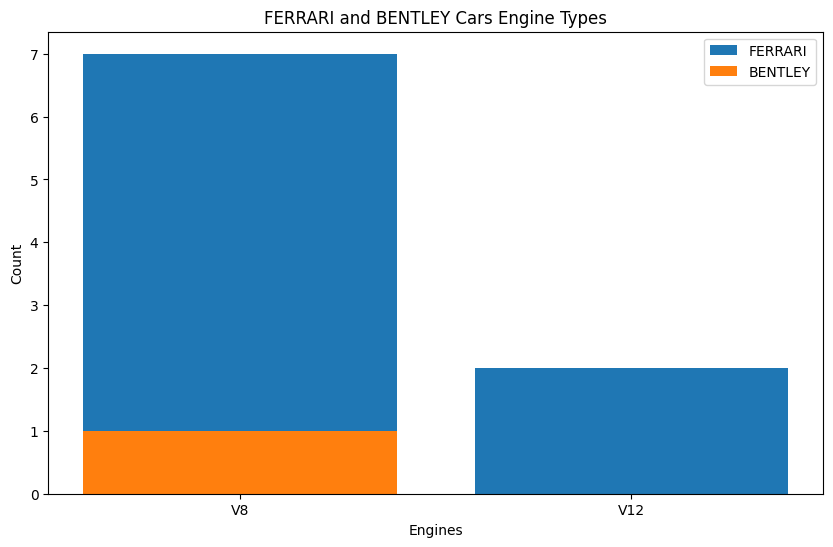

In [24]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

Ferrari_cars = df[df['Company Names'] == 'FERRARI']
Bentley_cars = df[df['Company Names'] == 'BENTLEY']

Ferrari_engine_types = Ferrari_cars['Engines'].value_counts()
Bentley_engine_types = Bentley_cars['Engines'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(Ferrari_engine_types.index, Ferrari_engine_types.values, label='FERRARI')
plt.bar(Bentley_engine_types.index, Bentley_engine_types.values, label='BENTLEY')
plt.xlabel('Engines')
plt.ylabel('Count')
plt.title('FERRARI and BENTLEY Cars Engine Types')
plt.legend()
plt.show()

In [25]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


df['Performance(0 - 100 )KM/H'] = pd.to_numeric(df['Performance(0 - 100 )KM/H'], errors='coerce')


top_10_fastest_cars = df.sort_values(by='Performance(0 - 100 )KM/H', ascending=True).head(10)


print("Top 10 Fastest Cars (0-100 km/h Performance):")
print(top_10_fastest_cars[['Cars Names', 'Performance(0 - 100 )KM/H']])


output_path = "top_10_fastest_cars.csv"
top_10_fastest_cars[['Cars Names', 'Performance(0 - 100 )KM/H']].to_csv(output_path, index=False)
print(f"\nTop 10 fastest cars saved to {output_path}")

Top 10 Fastest Cars (0-100 km/h Performance):
                                  Cars Names  Performance(0 - 100 )KM/H
554                              911 Turbo S                        2.6
553                                911 Turbo                        2.7
561                           Taycan Turbo S                        2.8
556                               911 GT3 RS                        3.2
560                             Taycan Turbo                        3.2
568                        718 Cayman GT4 RS                        3.2
576  Panamera Turbo S E-Hybrid Sport Turismo                        3.2
591                         Cayenne Turbo GT                        3.3
555                                  911 GT3                        3.4
551                           911 Carrera 4S                        3.4

Top 10 fastest cars saved to top_10_fastest_cars.csv
